# 🏆 Pronostics CDM 2026 — Phase de groupes (analyse explorable)

Analyse des pronostics de scores des **72 matchs de phase de groupes** de la Coupe du Monde 2026
(48 équipes, 12 groupes), avec **Plotly Express** (graphiques interactifs : survol, zoom, légendes cliquables).

**Méthodologie hybride**
1. **Modèle Poisson** — buts attendus dérivés des notes **Elo** (+ avantage hôte) → score + probas V/N/D.
2. **Multi-agents** — 12 agents prédicteurs (forme, effectifs, blessures) ajustent ; 4 critiques challengent.
3. **Synthèse** — `data/predictions.csv` ; classements et qualifiés calculés ici.

> ⏱️ Le tournoi a débuté le 11/06/2026. **J1 = résultats réels** (groupes A–H), **J2/J3 = pronostics**.
> Groupes I–L : entièrement pronostiqués (non joués au 16/06).

*Notebook rejouable : modifiez les Elo (`data/team_ratings.csv`) ou le modèle (`model_pronos.py`),
relancez `build_predictions.py`, puis ce notebook.*

In [1]:
import sys, os, json
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import display

# Rendu en SVG statique : figures visibles directement sur GitHub (qui n'exécute pas le JS).
# Pour l'interactivité (survol/zoom), relancer la cellule avec pio.renderers.default="notebook".
pio.renderers.default = "svg"
TEMPLATE = "plotly_white"

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
import model_pronos as mp
import standings as S

groupes = json.load(open("data/groups.json"))["groupes"]
ratings = pd.read_csv("data/team_ratings.csv")
fixtures = pd.read_csv("data/fixtures.csv")
predictions = pd.read_csv("data/predictions.csv")
elo = dict(zip(ratings.equipe, ratings.elo))
print(f"{len(ratings)} équipes · {len(fixtures)} matchs · {len(predictions)} pronostics")

48 équipes · 72 matchs · 72 pronostics


## 1. Forces en présence (Elo)

L'Elo est le moteur du modèle (source : eloratings.net / classement FIFA juin 2026 + recherche agents).
Survolez les barres ; cliquez la légende pour isoler un groupe.

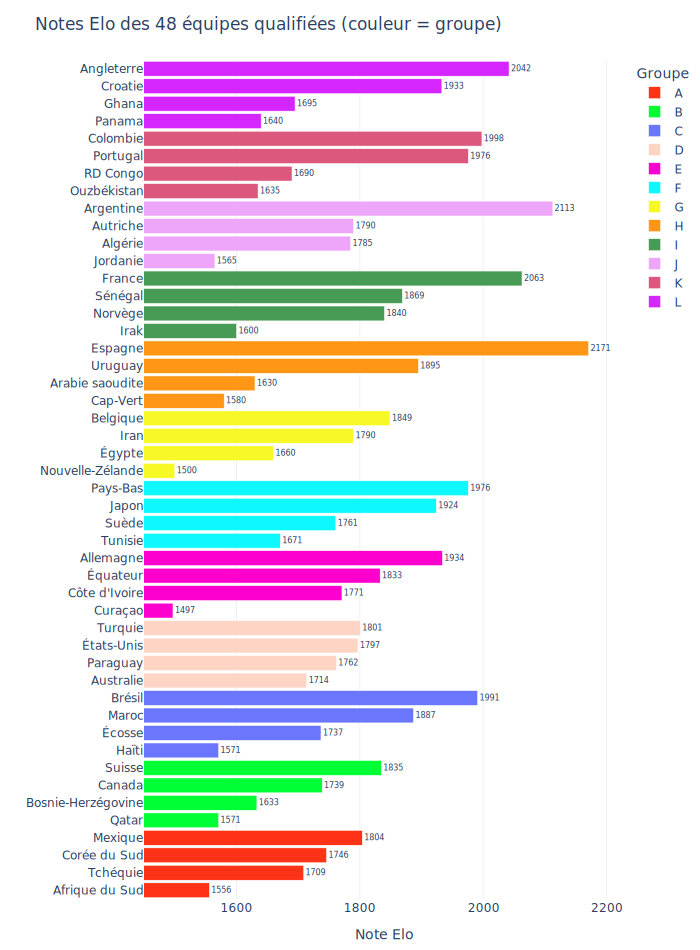

In [2]:
order = ratings.sort_values(["groupe", "elo"], ascending=[True, True])
fig = px.bar(order, x="elo", y="equipe", color="groupe", orientation="h",
             text="elo", hover_data={"fifa_rank": True, "elo": True, "groupe": True},
             title="Notes Elo des 48 équipes qualifiées (couleur = groupe)",
             labels={"elo": "Note Elo", "equipe": "", "groupe": "Groupe", "fifa_rank": "Rang FIFA"},
             template=TEMPLATE, height=950, color_discrete_sequence=px.colors.qualitative.Light24)
fig.update_traces(textposition="outside", textfont_size=8)
fig.update_xaxes(range=[1450, 2230])
fig.update_layout(legend_title_text="Groupe", bargap=0.15,
                  margin=dict(l=10, r=10, t=60, b=10))
fig.show()

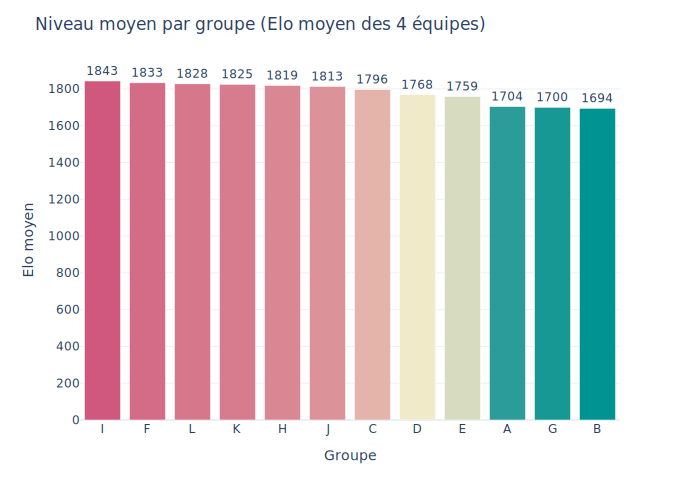

In [3]:
# Force moyenne par groupe (quels sont les groupes les plus relevés ?)
gm = ratings.groupby("groupe").elo.agg(["mean", "min", "max"]).reset_index()
gm = gm.sort_values("mean", ascending=False)
fig = px.bar(gm, x="groupe", y="mean", color="mean", text=gm["mean"].round(0),
             title="Niveau moyen par groupe (Elo moyen des 4 équipes)",
             labels={"mean": "Elo moyen", "groupe": "Groupe"},
             template=TEMPLATE, color_continuous_scale="Tealrose")
fig.update_traces(textposition="outside")
fig.update_layout(coloraxis_showscale=False, margin=dict(t=60))
fig.show()

## 2. Le modèle de Poisson

Pour un match : `dr = Δelo (+ avantage hôte)` → *supremacy* `sup = 3.6·tanh(dr/350)` (bornée) →
buts totaux `TG = 2.5 + 0.35·|sup|` → `λ_dom=(TG+sup)/2`, `λ_ext=(TG-sup)/2`.
Deux lois de Poisson indépendantes donnent la matrice des scores et les probabilités V/N/D.

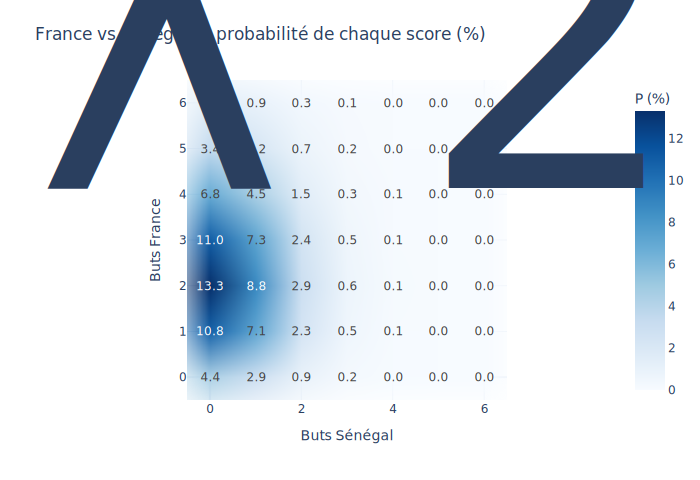

In [4]:
def heatmap_match(dom, ext, n=6):
    lam_d, lam_e = mp.lambdas(elo[dom], elo[ext], dom, ext)
    M = mp.matrice_scores(lam_d, lam_e, n) * 100
    fig = px.imshow(M, text_auto=".1f", origin="lower", color_continuous_scale="Blues",
                    labels=dict(x=f"Buts {ext}", y=f"Buts {dom}", color="P (%)"),
                    x=list(range(n+1)), y=list(range(n+1)),
                    title=f"{dom} vs {ext} — probabilité de chaque score (%)<br>"
                          f"<sub>λ {lam_d:.2f}–{lam_e:.2f} · "
                          f"V/N/D = {mp.pronostic(elo[dom],elo[ext],dom,ext)['p_victoire_dom']:.0%}/"
                          f"{mp.pronostic(elo[dom],elo[ext],dom,ext)['p_nul']:.0%}/"
                          f"{mp.pronostic(elo[dom],elo[ext],dom,ext)['p_victoire_ext']:.0%}</sub>",
                    template=TEMPLATE, height=480)
    fig.update_layout(margin=dict(t=80))
    return fig

heatmap_match("France", "Sénégal").show()

*Essayez un autre match en changeant les équipes ci-dessous (n'importe quelle paire d'équipes du tournoi).*

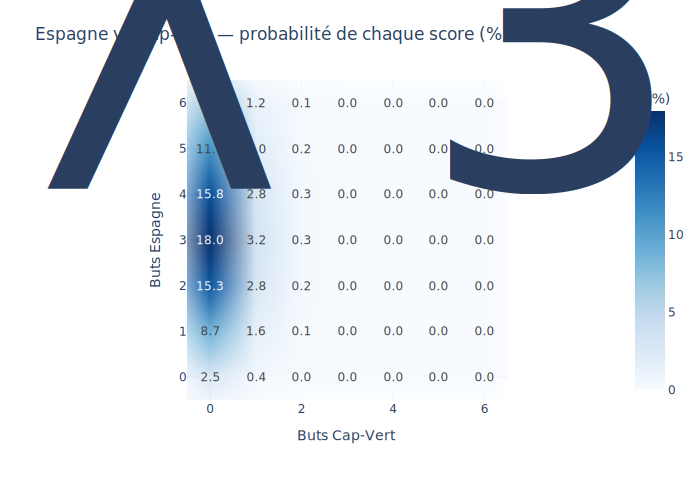

In [5]:
heatmap_match("Espagne", "Cap-Vert").show()

## 3. Validation : le modèle face à la J1 réelle

Le modèle « avant-match » (Elo seul) a-t-il anticipé la J1 déjà jouée (groupes A–H) ?

In [6]:
base = pd.read_csv("data/predictions_baseline.csv")
bcols = ["groupe","journee","equipe_dom","equipe_ext","score_modele","buts_dom_modele","buts_ext_modele"]
joues = fixtures[fixtures.statut == "joue"].copy()
val = joues.merge(base[bcols], on=["groupe","journee","equipe_dom","equipe_ext"])
def issue(a, b): return "V" if a > b else ("D" if a < b else "N")
rows = []
for _, r in val.iterrows():
    ra, rb = map(int, str(r.score_reel).split("-"))
    rows.append({"Match": f"{r.equipe_dom} – {r.equipe_ext}", "Réel": r.score_reel,
                 "Modèle": r.score_modele,
                 "Issue réelle": issue(ra, rb),
                 "Issue modèle": issue(r.buts_dom_modele, r.buts_ext_modele),
                 "Issue OK": "✅" if issue(ra, rb) == issue(r.buts_dom_modele, r.buts_ext_modele) else "❌"})
vdf = pd.DataFrame(rows)
taux = (vdf["Issue OK"] == "✅").mean()
display(vdf)
print(f"Issues (V/N/D) correctes : {(vdf['Issue OK']=='✅').sum()}/{len(vdf)} = {taux:.0%}")

,Match,Réel,Modèle,Issue réelle,Issue modèle,Issue OK
0,Mexique – Afrique du Sud,2-0,2-0,V,V,✅
1,Corée du Sud – Tchéquie,2-1,1-1,V,N,❌
2,Canada – Bosnie-Herzégovine,1-1,2-0,N,V,❌
3,Qatar – Suisse,1-1,0-2,N,D,❌
4,Brésil – Maroc,1-1,1-0,N,V,❌
5,Haïti – Écosse,0-1,0-2,D,D,✅
6,États-Unis – Paraguay,4-1,1-0,V,V,✅
7,Australie – Turquie,2-0,0-1,V,D,❌
8,Allemagne – Curaçao,7-1,3-0,V,V,✅
9,Côte d'Ivoire – Équateur,1-0,1-1,V,N,❌


Issues (V/N/D) correctes : 6/16 = 38%


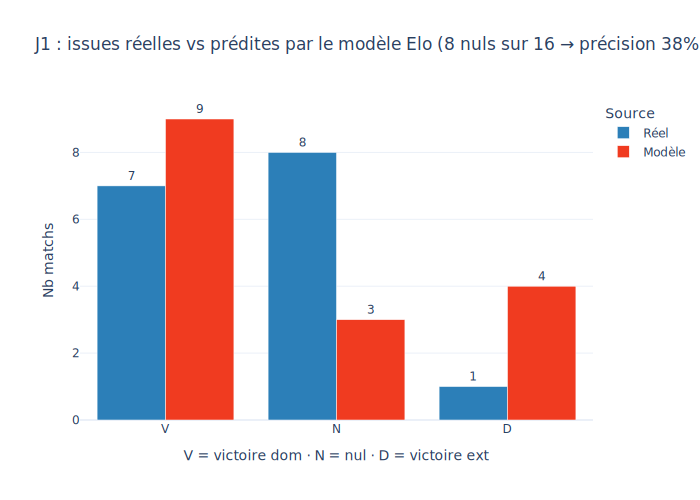

In [7]:
# Répartition des issues réelles vs prédites par le modèle (la J1 fut très nulle)
comp = pd.DataFrame({
    "Réel": vdf["Issue réelle"].value_counts(),
    "Modèle": vdf["Issue modèle"].value_counts(),
}).reindex(["V","N","D"]).fillna(0).reset_index().melt(
    id_vars="index", var_name="Source", value_name="Nb matchs").rename(columns={"index":"Issue"})
fig = px.bar(comp, x="Issue", y="Nb matchs", color="Source", barmode="group", text="Nb matchs",
             title="J1 : issues réelles vs prédites par le modèle Elo "
                   f"(8 nuls sur 16 → précision {taux:.0%})",
             labels={"Issue":"V = victoire dom · N = nul · D = victoire ext"},
             template=TEMPLATE, color_discrete_map={"Réel":"#2c7fb8","Modèle":"#f03b20"})
fig.update_traces(textposition="outside")
fig.show()

La J1 fut **exceptionnellement nulle et surprenante** (Espagne 0-0 Cap-Vert, Belgique 1-1 Égypte…).
Le modèle Elo, qui prédit rarement le nul, en a logiquement manqué beaucoup — d'où l'intérêt de la
couche d'experts pour les pronostics J2/J3.

## 4. Les 72 pronostics (tableau interactif)

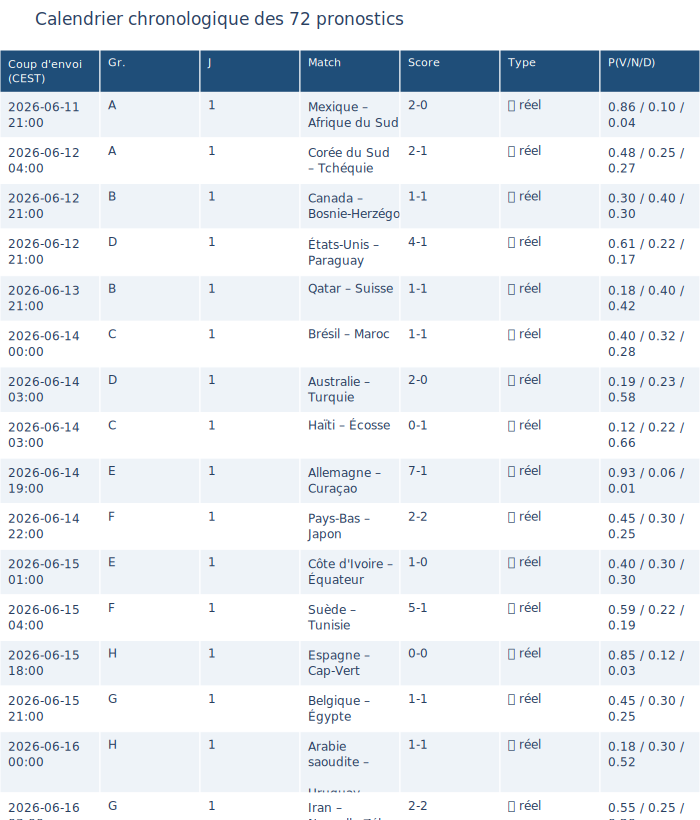

In [8]:
show = predictions.copy()
show["Match"] = show.equipe_dom + " – " + show.equipe_ext
show["Score"] = show.buts_dom.astype(str) + "-" + show.buts_ext.astype(str)
show["Type"] = np.where(show.statut == "joue", "✅ réel", "🔮 prono")
show["P(V/N/D)"] = (show.p_victoire_dom.map("{:.2f}".format) + " / "
                    + show.p_nul.map("{:.2f}".format) + " / "
                    + show.p_victoire_ext.map("{:.2f}".format))
cols = {"kickoff_cest":"Coup d'envoi (CEST)","groupe":"Gr.","journee":"J",
        "Match":"Match","Score":"Score","Type":"Type","P(V/N/D)":"P(V/N/D)"}
tab = show.sort_values("kickoff_utc")[list(cols)].rename(columns=cols)
fig = go.Figure(go.Table(
    header=dict(values=list(tab.columns), fill_color="#1f4e79",
                font=dict(color="white", size=11), align="left"),
    cells=dict(values=[tab[c] for c in tab.columns],
               fill_color=[["#eef3f8","white"]*40], align="left", height=22)))
fig.update_layout(title="Calendrier chronologique des 72 pronostics",
                  margin=dict(t=50, l=0, r=0, b=0), height=820)
fig.show()

## 4b. Notre modèle vs mpp.football

Comparaison de la **probabilité de victoire à domicile** entre notre modèle et les probas mpp.football
(export utilisateur), pour les 56 matchs à venir. Points sur la diagonale = accord parfait.

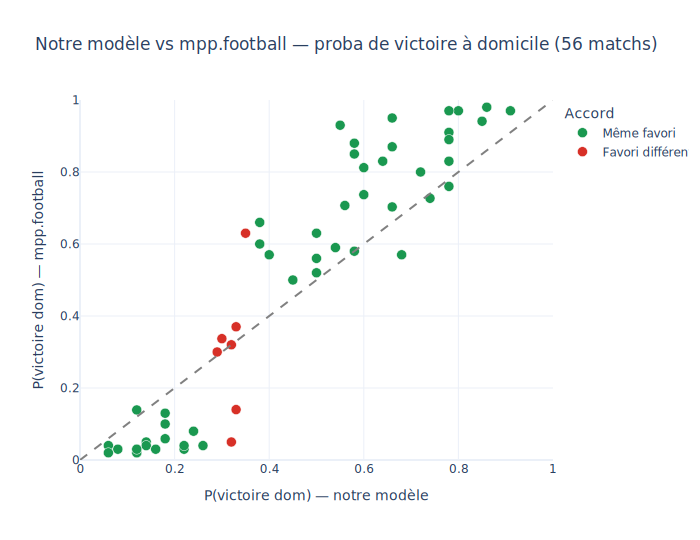

Même favori (issue la plus probable) que mpp : 49/56 = 88%


In [9]:
cmp = predictions[predictions.p_mpp_dom.astype(str) != ""].dropna(subset=["p_mpp_dom"]).copy()
for c in ["p_mpp_dom", "p_mpp_nul", "p_mpp_ext"]:
    cmp[c] = cmp[c].astype(float)
cmp["Match"] = cmp.equipe_dom + " – " + cmp.equipe_ext
fav_model = np.sign(cmp.p_victoire_dom - cmp.p_victoire_ext)
fav_mpp = np.sign(cmp.p_mpp_dom - cmp.p_mpp_ext)
cmp["Accord"] = np.where(fav_model == fav_mpp, "Même favori", "Favori différent")
fig = px.scatter(cmp, x="p_victoire_dom", y="p_mpp_dom", color="Accord", hover_name="Match",
                 hover_data={"groupe": True, "p_victoire_dom": ":.2f", "p_mpp_dom": ":.2f"},
                 labels={"p_victoire_dom": "P(victoire dom) — notre modèle",
                         "p_mpp_dom": "P(victoire dom) — mpp.football"},
                 title="Notre modèle vs mpp.football — proba de victoire à domicile (56 matchs)",
                 color_discrete_map={"Même favori": "#1a9850", "Favori différent": "#d73027"},
                 template=TEMPLATE, height=540)
fig.add_shape(type="line", x0=0, y0=0, x1=1, y1=1, line=dict(dash="dash", color="gray"))
fig.update_traces(marker=dict(size=10, line=dict(width=0.5, color="white")))
fig.update_xaxes(range=[0, 1]); fig.update_yaxes(range=[0, 1])
fig.show()
acc = (cmp["Accord"] == "Même favori").mean()
print(f"Même favori (issue la plus probable) que mpp : {(cmp['Accord']=='Même favori').sum()}/{len(cmp)} = {acc:.0%}")

## 5. Classements de groupe (départages FIFA)

In [10]:
classements = S.tous_classements(predictions)
def colorise(df):
    sty = df.style.format({"diff":"{:+d}"}).background_gradient(
        subset=["pts"], cmap="Greens").set_caption("")
    return sty
for g in sorted(classements):
    print(f"───────── Groupe {g} ─────────")
    display(colorise(classements[g]))

───────── Groupe A ─────────


,equipe,J,G,N,P,bp,bc,diff,pts
rang,,,,,,,,,
1,Corée du Sud,3,2,1,0,5,2,+3,7
2,Mexique,3,1,2,0,4,2,+2,5
3,Tchéquie,3,1,1,1,3,3,+0,4
4,Afrique du Sud,3,0,0,3,0,5,-5,0


───────── Groupe B ─────────


,equipe,J,G,N,P,bp,bc,diff,pts
rang,,,,,,,,,
1,Suisse,3,2,1,0,5,2,+3,7
2,Canada,3,1,1,1,4,3,+1,4
3,Bosnie-Herzégovine,3,1,1,1,3,4,-1,4
4,Qatar,3,0,1,2,2,5,-3,1


───────── Groupe C ─────────


...

,equipe,J,G,N,P,bp,bc,diff,pts
rang,,,,,,,,,
1,Argentine,3,3,0,0,6,2,+4,9
2,Autriche,3,1,1,1,4,3,+1,4
3,Algérie,3,1,1,1,3,3,+0,4
4,Jordanie,3,0,0,3,1,6,-5,0


───────── Groupe K ─────────


,equipe,J,G,N,P,bp,bc,diff,pts
rang,,,,,,,,,
1,Portugal,3,2,1,0,6,1,+5,7
2,Colombie,3,2,1,0,5,2,+3,7
3,RD Congo,3,1,0,2,3,5,-2,3
4,Ouzbékistan,3,0,0,3,1,7,-6,0


───────── Groupe L ─────────


,equipe,J,G,N,P,bp,bc,diff,pts
rang,,,,,,,,,
1,Angleterre,3,3,0,0,6,0,+6,9
2,Croatie,3,2,0,1,4,4,+0,6
3,Ghana,3,0,1,2,2,5,-3,1
4,Panama,3,0,1,2,2,5,-3,1


## 6. Qualifiés pour les 1/16

Format 2026 : **32 qualifiés** = 12 premiers + 12 deuxièmes + **8 meilleurs troisièmes**.

In [11]:
premiers, deuxiemes, meilleurs3, df3 = S.qualifies(classements)
q1 = {e for _, e in premiers}; q2 = {e for _, e in deuxiemes}; q3 = set(meilleurs3.equipe)
tabq = pd.DataFrame({
    "1ers de groupe": [f"{g} · {e}" for g, e in premiers],
    "2es de groupe": [f"{g} · {e}" for g, e in deuxiemes],
    "Meilleurs 3es": [f"{r.groupe} · {r.equipe}" for _, r in meilleurs3.reset_index(drop=True).iterrows()] + [""]*(12-len(meilleurs3)),
})
tabq.index = [f"#{i+1}" for i in range(12)]
display(tabq)

,1ers de groupe,2es de groupe,Meilleurs 3es
#1,A · Corée du Sud,A · Mexique,F · Japon
#2,B · Suisse,B · Canada,E · Équateur
#3,C · Brésil,C · Maroc,J · Algérie
#4,D · États-Unis,D · Australie,I · Norvège
#5,E · Allemagne,E · Côte d'Ivoire,A · Tchéquie
#6,F · Suède,F · Pays-Bas,B · Bosnie-Herzégovine
#7,G · Belgique,G · Égypte,D · Turquie
#8,H · Espagne,H · Uruguay,K · RD Congo
#9,I · France,I · Sénégal,
#10,J · Argentine,J · Autriche,


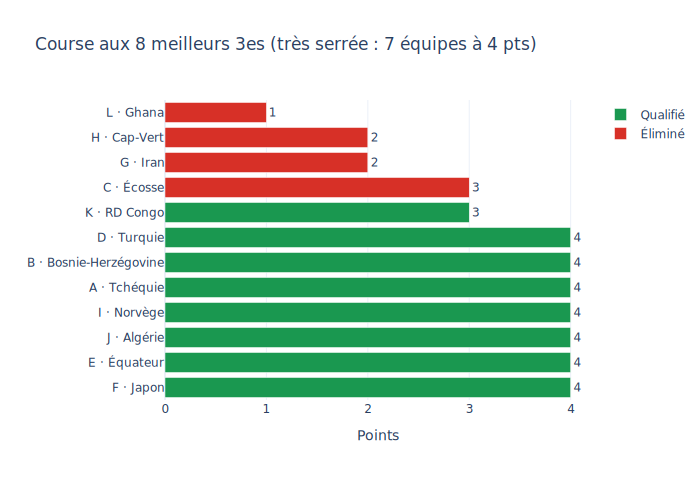

In [12]:
# Course aux meilleurs 3es : qui passe, qui sort ? (8 premiers qualifiés)
d = df3.reset_index(drop=True).copy()
d["statut"] = ["Qualifié"]*8 + ["Éliminé"]*(len(d)-8)
d["label"] = d.groupe + " · " + d.equipe
fig = px.bar(d, x="pts", y="label", color="statut", orientation="h",
             text="pts", hover_data={"diff":True,"bp":True,"pts":True,"label":False},
             category_orders={"label": d.label.tolist()[::-1]},
             color_discrete_map={"Qualifié":"#1a9850","Éliminé":"#d73027"},
             title="Course aux 8 meilleurs 3es (très serrée : 7 équipes à 4 pts)",
             labels={"pts":"Points","label":"","statut":""}, template=TEMPLATE, height=480)
fig.update_traces(textposition="outside")
fig.show()

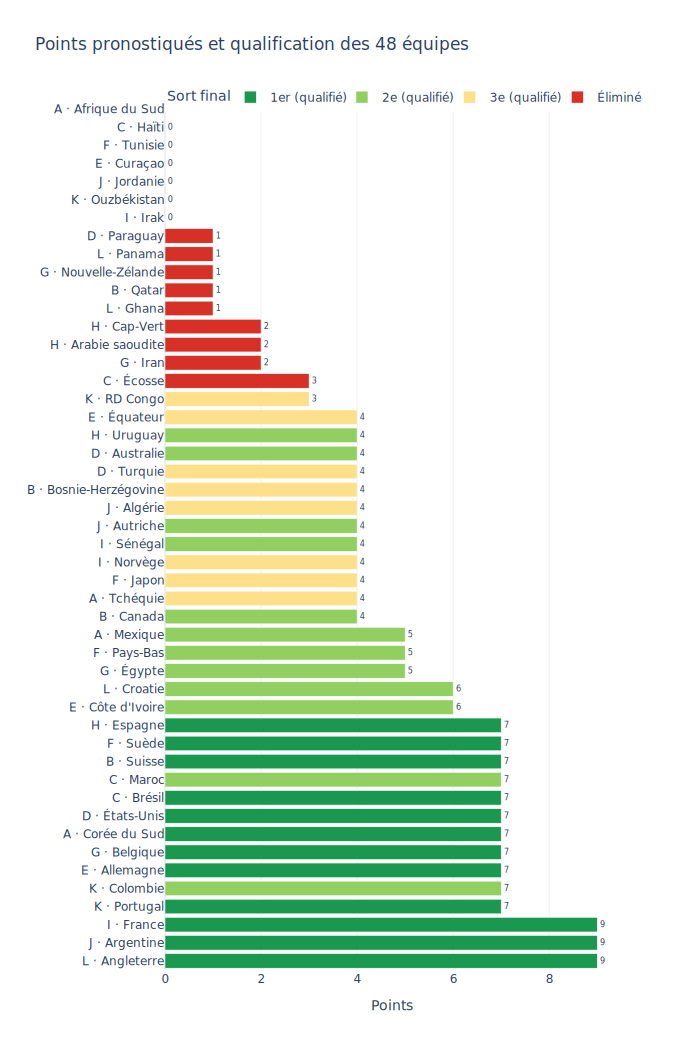

In [13]:
# Points finaux des 48 équipes, colorés par sort final
def statut_eq(e):
    if e in q1: return "1er (qualifié)"
    if e in q2: return "2e (qualifié)"
    if e in q3: return "3e (qualifié)"
    return "Éliminé"
allt = pd.concat([t.assign(groupe=g) for g, t in classements.items()])
allt = allt.reset_index().rename(columns={"index":"rang"})
allt["statut"] = allt.equipe.map(statut_eq)
allt["label"] = allt.groupe + " · " + allt.equipe
allt = allt.sort_values("pts")
order_map = {"1er (qualifié)":0,"2e (qualifié)":1,"3e (qualifié)":2,"Éliminé":3}
fig = px.bar(allt, x="pts", y="label", color="statut", orientation="h", text="pts",
             hover_data={"groupe":True,"diff":True,"bp":True,"bc":True,"label":False},
             category_orders={"label": allt.label.tolist(),
                              "statut": sorted(allt.statut.unique(), key=order_map.get)},
             color_discrete_map={"1er (qualifié)":"#1a9850","2e (qualifié)":"#91cf60",
                                 "3e (qualifié)":"#fee08b","Éliminé":"#d73027"},
             title="Points pronostiqués et qualification des 48 équipes",
             labels={"pts":"Points","label":"","statut":"Sort final"},
             template=TEMPLATE, height=1050)
fig.update_traces(textposition="outside", textfont_size=8)
fig.update_layout(legend=dict(orientation="h", y=1.02, x=0))
fig.show()

## 7. Frise chronologique des matchs

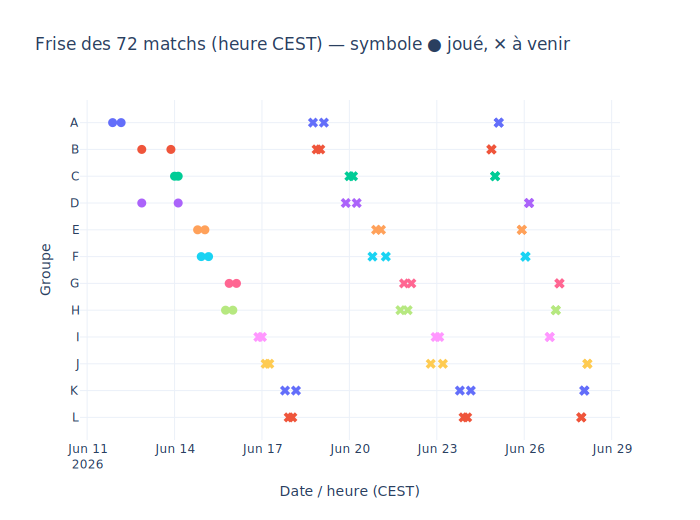

In [14]:
tl = predictions.copy()
tl["dt"] = pd.to_datetime(tl["kickoff_cest"])
tl["Match"] = tl.equipe_dom + " – " + tl.equipe_ext
tl["Type"] = np.where(tl.statut == "joue", "joué", "à venir")
fig = px.scatter(tl, x="dt", y="groupe", color="groupe", symbol="Type",
                 hover_name="Match", hover_data={"dt":"|%a %d/%m %Hh%M","groupe":False},
                 symbol_map={"joué":"circle","à venir":"x"},
                 title="Frise des 72 matchs (heure CEST) — symbole ● joué, ✕ à venir",
                 labels={"dt":"Date / heure (CEST)","groupe":"Groupe"},
                 template=TEMPLATE, height=520)
fig.update_traces(marker_size=9)
fig.update_yaxes(categoryorder="category descending")
fig.update_layout(showlegend=False)
fig.show()

## 8. Pour aller plus loin

- Le départage des **meilleurs 3es** est extrêmement serré : un seul but change un qualifié.
- Modifiez un Elo (`data/team_ratings.csv`) ou un paramètre (`model_pronos.py`), relancez
  `python build_predictions.py` puis ce notebook pour voir l'impact en direct.
- **Probas mpp.football** : non disponibles publiquement (appli authentifiée). Si vous fournissez
  un export, une colonne `proba_mpp` pourra être ajoutée à `predictions.csv` et tracée ici.
- Hors périmètre : la phase à élimination directe (1/16 → finale).